In [362]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("Setup successful!")

Setup successful!


In [363]:
df = pd.read_csv(r"C:\Users\hphhhhphhhphp\OneDrive\Desktop\Hackathon\DataSet.csv")
df.head()

,Unnamed: 0,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F3915,F3916,F3917,F3918,F3919,F3920,F3921,F3922,F3923,F3924
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,0,1,0,0
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,1,0,0,0
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,0,1,0,0
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,0,1,0,0
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,1,0,0,1,0,1,0,0,0


In [364]:
df.shape

(9082, 3925)

In [365]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9082 entries, 0 to 9081
Columns: 3925 entries, Unnamed: 0 to F3924
dtypes: float64(3876), int64(41), object(8)
memory usage: 272.0+ MB


In [366]:
print(df.dtypes.value_counts())

float64    3876
int64        41
object        8
Name: count, dtype: int64


In [367]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print(cat_cols)

['F2230', 'F3886', 'F3888', 'F3889', 'F3890', 'F3891', 'F3892', 'F3893']


In [368]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing.head(20))

F3133    9082
F2312    9082
F3179    9082
F3668    9082
F3182    9082
F3773    9082
F3776    9082
F3233    9082
F2455    9082
F293     9082
F2863    9082
F2814    9082
F2458    9082
F2914    9082
F3077    9082
F3027    9082
F131     9082
F182     9082
F3030    9082
F2756    9082
dtype: int64


In [369]:
empty_cols = df.columns[df.isnull().all()]

print("Number of completely empty columns:", len(empty_cols))

df = df.drop(columns=empty_cols)

print(df.shape)

Number of completely empty columns: 63
(9082, 3862)


In [370]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing.head(20))
print("Columns with missing values:", len(missing))

F2911    9081
F2600    9081
F2908    9081
F2603    9081
F181     9081
F183     9081
F184     9081
F186     9081
F2804    9081
F2801    9081
F2915    9080
F2913    9080
F2809    9080
F2806    9080
F3024    9080
F2916    9080
F2918    9080
F3021    9080
F3022    9080
F3023    9080
dtype: int64
Columns with missing values: 3772


In [371]:
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_pct.sort_values(ascending=False).head(20)

F2911    99.988989
F2908    99.988989
F2600    99.988989
F2603    99.988989
F181     99.988989
F186     99.988989
F183     99.988989
F184     99.988989
F2801    99.988989
F2804    99.988989
F3129    99.977978
F3130    99.977978
F2811    99.977978
F2809    99.977978
F3024    99.977978
F2915    99.977978
F3127    99.977978
F3128    99.977978
F2806    99.977978
F2808    99.977978
dtype: float64

In [372]:
print("Columns > 99% missing :", (missing_pct > 99).sum())
print("Columns > 95% missing :", (missing_pct > 95).sum())
print("Columns > 90% missing :", (missing_pct > 90).sum())
print("Columns > 80% missing :", (missing_pct > 80).sum())

Columns > 99% missing : 144
Columns > 95% missing : 298
Columns > 90% missing : 453
Columns > 80% missing : 845


In [373]:
missing_pct = (df.isnull().sum() / len(df)) * 100

cols_to_drop = missing_pct[missing_pct > 95].index

df = df.drop(columns=cols_to_drop)

print(df.shape)

(9082, 3564)


In [374]:
cat_cols = df.select_dtypes(include="object").columns.tolist()

print(cat_cols)

['F2230', 'F3886', 'F3888', 'F3889', 'F3890', 'F3891', 'F3892', 'F3893']


In [375]:
df.shape

(9082, 3564)

In [376]:
X = df.drop("F3924", axis=1)
y = df["F3924"]

In [377]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [378]:
print(y_train.value_counts())
print(y_test.value_counts())

F3924
0    7200
1      65
Name: count, dtype: int64
F3924
0    1801
1      16
Name: count, dtype: int64


In [379]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

In [380]:
print("Numeric Features:", len(numeric_features))
print("Categorical Features:", len(categorical_features))

Numeric Features: 3555
Categorical Features: 8


In [381]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


In [382]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

In [383]:
from sklearn.preprocessing import OneHotEncoder

In [384]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [385]:
from sklearn.compose import ColumnTransformer

In [386]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [387]:
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 Index(['Unnamed: 0', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9',
       ...
       'F3914', 'F3915', 'F3916', 'F3917', 'F3918', 'F3919', 'F3920', 'F3921',
       'F3922', 'F3923'],
      dtype='object', length=3555)),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['F2230', 'F3886', 'F3888', 'F3889', 'F3890', 'F3891', 'F3892', 'F3893'], dtype='object'))])


In [388]:
df["Unnamed: 0"].head()

0    1
1    2
2    3
3    4
4    5
Name: Unnamed: 0, dtype: int64

In [389]:
df = df.drop("Unnamed: 0", axis=1)

In [390]:
X = df.drop("F3924", axis=1)
y = df["F3924"]

In [391]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [392]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     LogisticRegression(
         max_iter=1000,
         class_weight="balanced"
     ))
])

In [393]:
print("Unnamed: 0" in df.columns)

False


In [394]:

print(df.shape)

(9082, 3563)


In [395]:
X = df.drop("F3924", axis=1)
y = df["F3924"]

In [396]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

In [397]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [398]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [399]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     LogisticRegression(
         max_iter=1000,
         class_weight="balanced"
     ))
])

In [400]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     XGBClassifier(
         n_estimators=300,
         max_depth=6,
         learning_rate=0.05,
         subsample=0.8,
         colsample_bytree=0.8,
         scale_pos_weight=111,
         random_state=42,
         eval_metric="logloss"
     ))
])

In [401]:
xgb_model.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [402]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

In [403]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1801
           1       1.00      1.00      1.00        16

    accuracy                           1.00      1817
   macro avg       1.00      1.00      1.00      1817
weighted avg       1.00      1.00      1.00      1817

[[1801    0]
 [   0   16]]
ROC-AUC: 1.0


In [404]:
print(X.shape)
print(df.shape)


(9082, 3562)
(9082, 3563)


In [405]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

target_corr = numeric_df.drop(columns=["F3924"]).corrwith(
    numeric_df["F3924"]
).abs()

target_corr = target_corr.sort_values(ascending=False)

print(target_corr.head(20))

c:\Users\hphhhhphhhphp\OneDrive\Desktop\Hackathon\venv\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\hphhhhphhhphp\OneDrive\Desktop\Hackathon\venv\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


F3912    0.969066
F515     0.136986
F518     0.126906
F2578    0.118976
F255     0.113115
F2285    0.112599
F285     0.111709
F283     0.111696
F2779    0.109818
F253     0.109353
F287     0.105882
F286     0.105848
F267     0.105331
F2686    0.097861
F3908    0.097022
F258     0.095736
F159     0.093080
F256     0.091856
F270     0.090042
F2481    0.086164
dtype: float64


In [406]:
df["F3912"].describe()

count    9082.000000
mean        0.009029
std         0.094596
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: F3912, dtype: float64

In [407]:
df.groupby("F3924")["F3912"].describe()

,count,mean,std,min,25%,50%,75%,max
F3924,,,,,,,,
0,9001.0,0.000333,0.018254,0.0,0.0,0.0,0.0,1.0
1,81.0,0.975309,0.156150,0.0,1.0,1.0,1.0,1.0


In [408]:
df_no_f3912 = df.drop(columns=["F3912"])

In [409]:
print(df_no_f3912.shape)
print("F3912" in df_no_f3912.columns)

(9082, 3562)
False


In [410]:
X = df_no_f3912.drop("F3924", axis=1)
y = df_no_f3912["F3924"]

In [411]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [412]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print(len(numeric_features))
print(len(categorical_features))

3553
8


In [413]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [414]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",
     XGBClassifier(
         n_estimators=300,
         max_depth=6,
         learning_rate=0.05,
         subsample=0.8,
         colsample_bytree=0.8,
         scale_pos_weight=111,
         random_state=42,
         eval_metric="logloss"
     ))
])

In [452]:
xgb_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [419]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

In [420]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1801
           1       1.00      1.00      1.00        16

    accuracy                           1.00      1817
   macro avg       1.00      1.00      1.00      1817
weighted avg       1.00      1.00      1.00      1817

[[1801    0]
 [   0   16]]
ROC-AUC: 1.0


In [421]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=123
)

In [422]:
xgb_model.fit(X_train2, y_train2)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [423]:
y_pred2 = xgb_model.predict(X_test2)

y_prob2 = xgb_model.predict_proba(X_test2)[:, 1]

In [451]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test2, y_pred2))
print(confusion_matrix(y_test2, y_pred2))
print("ROC-AUC:", roc_auc_score(y_test2, y_prob2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1801
           1       1.00      1.00      1.00        16

    accuracy                           1.00      1817
   macro avg       1.00      1.00      1.00      1817
weighted avg       1.00      1.00      1.00      1817

[[1801    0]
 [   0   16]]
ROC-AUC: 1.0


In [425]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.named_steps["classifier"].feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df.head(20))

                   feature  importance
3528            num__F3898    0.122845
3555      cat__F2230_Oct25    0.089226
3543            num__F3914    0.084104
187              num__F228    0.057467
1808            num__F1922    0.049433
3449            num__F3812    0.047033
3388            num__F3749    0.042736
3554      cat__F2230_Nov25    0.041027
6405  cat__F3888_7-14-2009    0.039457
3556      cat__F2230_Sep25    0.033795
3548            num__F3919    0.026631
3442            num__F3805    0.026478
3537            num__F3907    0.025731
3553      cat__F2230_Dec25    0.022810
1854            num__F1968    0.022250
3444            num__F3807    0.020625
3345            num__F3706    0.018897
2545            num__F2786    0.018880
2321            num__F2489    0.016821
1588            num__F1702    0.016072


In [426]:
import joblib

joblib.dump(xgb_model, "mule_account_detector.pkl")

print("Model saved successfully")


Model saved successfully


In [427]:
loaded_model = joblib.load("mule_account_detector.pkl")

print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


In [428]:
sample = X_test.iloc[[0]]

prob = loaded_model.predict_proba(sample)[0][1]

print(prob)

0.00012436451


In [429]:
risk_score = round(prob * 100)

print(risk_score)

0


In [430]:
def get_risk_level(score):
    if score <= 30:
        return "Low"

    elif score <= 60:
        return "Medium"

    elif score <= 80:
        return "High"

    else:
        return "Critical"

In [431]:
print(get_risk_level(97))

Critical


In [432]:
sample = X_test.iloc[[0]]

prob = loaded_model.predict_proba(sample)[0][1]

risk_score = round(prob * 100)

risk_level = get_risk_level(risk_score)

print("Fraud Probability:", prob)
print("Risk Score:", risk_score)
print("Risk Level:", risk_level)

Fraud Probability: 0.00012436451
Risk Score: 0
Risk Level: Low


In [433]:
print("Actual Label:", y_test.iloc[0])

Actual Label: 0


In [434]:
def generate_report(prob):
    risk_score = round(prob * 100)
    risk_level = get_risk_level(risk_score)

    report = f"""
Mule Account Investigation Report

Risk Score: {risk_score}/100
Risk Level: {risk_level}

Assessment:
The account was analyzed using an AI/ML-based mule account detection model.

Recommendation:
"""

    if risk_level == "Critical":
        report += "\n• Immediate investigation required\n• Review recent transactions\n• Verify customer identity"

    elif risk_level == "High":
        report += "\n• Enhanced monitoring recommended\n• Review transaction history"

    elif risk_level == "Medium":
        report += "\n• Monitor account activity"

    else:
        report += "\n• No immediate action required"

    return report

In [435]:
print(generate_report(prob))


Mule Account Investigation Report

Risk Score: 0/100
Risk Level: Low

Assessment:
The account was analyzed using an AI/ML-based mule account detection model.

Recommendation:

• No immediate action required


In [436]:
top_features = importance_df.head(10)

print(top_features)

                   feature  importance
3528            num__F3898    0.122845
3555      cat__F2230_Oct25    0.089226
3543            num__F3914    0.084104
187              num__F228    0.057467
1808            num__F1922    0.049433
3449            num__F3812    0.047033
3388            num__F3749    0.042736
3554      cat__F2230_Nov25    0.041027
6405  cat__F3888_7-14-2009    0.039457
3556      cat__F2230_Sep25    0.033795


In [437]:
top_feature_names = (
    importance_df["feature"]
    .head(5)
    .tolist()
)

def generate_explanation():
    text = "Top risk indicators identified by the model:\n\n"

    for feature in top_feature_names:
        text += f"• {feature}\n"

    return text


In [438]:
print(generate_explanation())

Top risk indicators identified by the model:

• num__F3898
• cat__F2230_Oct25
• num__F3914
• num__F228
• num__F1922



In [439]:
def full_report(prob):
    return (
        generate_report(prob)
        + "\n\n"
        + generate_explanation()
    )

In [440]:
print(full_report(prob))


Mule Account Investigation Report

Risk Score: 0/100
Risk Level: Low

Assessment:
The account was analyzed using an AI/ML-based mule account detection model.

Recommendation:

• No immediate action required

Top risk indicators identified by the model:

• num__F3898
• cat__F2230_Oct25
• num__F3914
• num__F228
• num__F1922



In [441]:
total_accounts = len(df)

suspicious_accounts = df["F3924"].sum()

legitimate_accounts = total_accounts - suspicious_accounts

fraud_rate = (suspicious_accounts / total_accounts) * 100

print("Total Accounts:", total_accounts)
print("Suspicious Accounts:", suspicious_accounts)
print("Legitimate Accounts:", legitimate_accounts)
print("Fraud Rate:", round(fraud_rate, 2), "%")

Total Accounts: 9082
Suspicious Accounts: 81
Legitimate Accounts: 9001
Fraud Rate: 0.89 %


In [442]:
all_probs = loaded_model.predict_proba(X)[:, 1]

all_scores = (all_probs * 100).round()

risk_levels = [get_risk_level(score) for score in all_scores]

import pandas as pd

risk_summary = pd.Series(risk_levels).value_counts()

print(risk_summary)

Low         9001
Critical      81
Name: count, dtype: int64


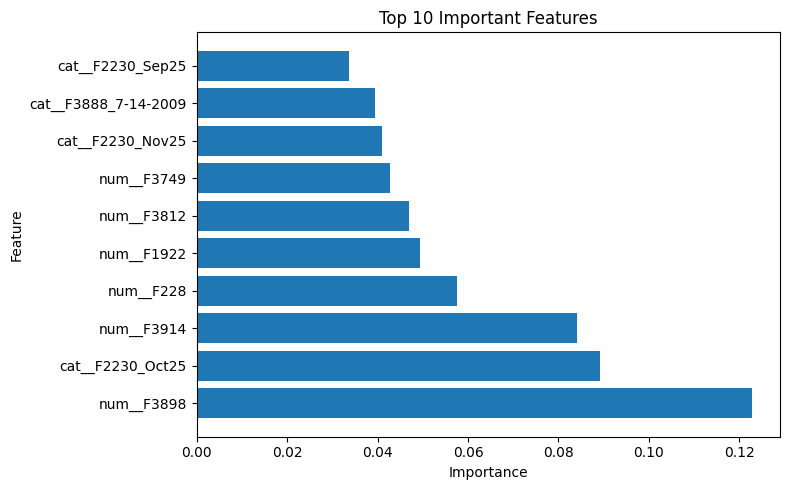

In [450]:
import matplotlib.pyplot as plt

top10 = importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["feature"], top10["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")
plt.tight_layout()

plt.show()

In [444]:
sample = X_test.head(5)

sample.to_csv("sample.csv", index=False)


In [449]:
df.duplicated().sum()

np.int64(0)